In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(5)

daily_temps = np.random.normal(
    loc=23,
    scale=2.5,
    size=30
)

print("Варіант 5 — Дніпро")
print("Денні температури:")
print(daily_temps)

print("\nСереднє:", daily_temps.mean())
print("Стандартне відхилення:", daily_temps.std())

Варіант 5 — Дніпро
Денні температури:
[24.10306872 22.17282462 29.07692797 22.36976968 23.2740246  26.95620279
 20.72691899 21.52090836 23.46900806 22.17532511 20.01808847 22.48780872
 22.10292763 24.50867901 18.83802868 21.24955241 25.87847752 27.64332752
 19.22205111 24.61211878 20.54848029 20.85786711 20.82030204 21.94373018
 25.49109957 24.78105318 23.14786061 22.0917228  23.00822211 22.73517389]

Середнє: 22.92771835022647
Стандартне відхилення: 2.3745246413055727


Середня температура згенерованої вибірки становить приблизно
22.93 °C, що близько до середньої липневої температури Дніпра
23 °C.

Значення не збігаються точно, оскільки вибірка складається
з випадково згенерованих денних температур.

In [2]:
mean = daily_temps.mean()
std = daily_temps.std()

dist = stats.norm(
    loc=mean,
    scale=std
)

print("Середнє (mean):", mean)
print("Стандартне відхилення (std):", std)

Середнє (mean): 22.92771835022647
Стандартне відхилення (std): 2.3745246413055727


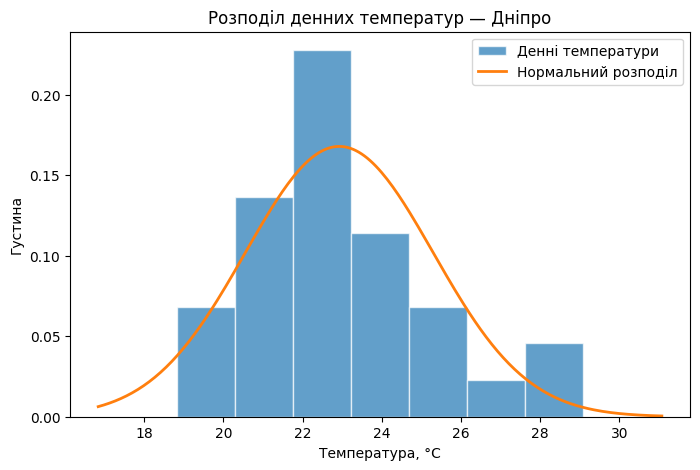

In [3]:
x = np.linspace(
    daily_temps.min() - 2,
    daily_temps.max() + 2,
    200
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    daily_temps,
    bins=7,
    density=True,
    edgecolor="white",
    alpha=0.7,
    label="Денні температури"
)

ax.plot(
    x,
    dist.pdf(x),
    linewidth=2,
    label="Нормальний розподіл"
)

ax.set_xlabel("Температура, °C")
ax.set_ylabel("Густина")
ax.set_title("Розподіл денних температур — Дніпро")
ax.legend()

plt.show()

Теоретична pdf-крива загалом проходить близько до верхівок
стовпців гістограми.

Форма гістограми приблизно відповідає нормальному розподілу,
хоча присутні певні відхилення.

Це нормально, оскільки вибірка містить лише 30 випадкових
спостережень, тому її форма не повинна ідеально повторювати
теоретичну нормальну криву.

In [4]:
lower = mean - std
upper = mean + std

probability = (
    dist.cdf(upper) -
    dist.cdf(lower)
)

print("Нижня межа:", lower)
print("Верхня межа:", upper)
print("Ймовірність:", probability)
print("Ймовірність у %:", probability * 100)

Нижня межа: 20.553193708920897
Верхня межа: 25.302242991532044
Ймовірність: 0.6826894921370861
Ймовірність у %: 68.26894921370861


Інтервал одного стандартного відхилення від середнього:

[20.55 °C; 25.30 °C]

Ймовірність потрапляння температури в цей діапазон
становить приблизно 0.683, або 68.27%.

Це практично збігається з правилом 68–95–99.7, згідно
з яким для нормального розподілу приблизно 68% значень
лежать у межах одного стандартного відхилення від середнього.

In [5]:
percentile_95 = dist.ppf(0.95)

print("95-й процентиль:", percentile_95)

95-й процентиль: 26.833463818763587


95-й процентиль підібраного нормального розподілу
становить приблизно 26.83 °C.

Це означає, що за нашою нормальною моделлю приблизно
95% денних температур знаходяться нижче 26.83 °C,
а приблизно 5% — вище цього значення.

Функція ppf() є оберненою до cdf().

cdf() отримує на вході конкретне значення температури
і повертає накопичену ймовірність.

ppf(), навпаки, отримує на вході накопичену ймовірність
і повертає значення температури, яке їй відповідає.

Контрольні питання

1. Яка різниця між pdf(x) і cdf(x)?

pdf(x) показує густину ймовірності нормального розподілу
в конкретній точці x. Значення pdf не є безпосередньо
ймовірністю потрапляння точно в цю точку.

cdf(x) показує накопичену ймовірність, тобто ймовірність
того, що випадкова величина буде меншою або дорівнюватиме x.

Отже, pdf описує густину розподілу, а cdf — накопичену
ймовірність до заданого значення.


2. Чому pdf(x) може бути більше 1?

pdf(x) є густиною ймовірності, а не самою ймовірністю.
Тому її значення в окремій точці може бути більшим за 1.

Ймовірність для неперервної випадкової величини визначається
площею під pdf-кривою на певному інтервалі.

Загальна площа під усією кривою дорівнює 1, тому це
не суперечить правилу, що ймовірність не може перевищувати 1.


3. Чому ppf() називають оберненою функцією до cdf()?

cdf() приймає значення випадкової величини x і повертає
накопичену ймовірність P(X ≤ x).

ppf() виконує обернену операцію: приймає ймовірність
і повертає значення x, якому вона відповідає.

Наприклад, ppf(0.95) повертає значення, нижче якого
знаходиться приблизно 95% розподілу.